In [2]:
# !/usr/bin/env python3 import sqlalchemy to connect to the PostgreSQL database 
# and perform data analysis for the e-commerce revenue intelligence project.
from sqlalchemy import create_engine

# Set Database connection parameters
username = "postgres"
password = "Pg070723"
host = "localhost"
port = "5432"
database = "ecommerce_analytics"

# Attempt to connect to the PostgreSQL database using SQLAlchemy's create_engine function.
try:
    engine = create_engine(
        f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}"
    )

    connection = engine.connect()

    # If the connection is successful, you can proceed with your data analysis tasks here.
    print("Connected successfully!")
# else if there is an error during the connection attempt, catch the exception and print the error message.
except Exception as e:
    print(e)

Connected successfully!


In [3]:
# copy cleaned data from the ecommerce_clean_data csv file to the ecommerce_analytics database
import pandas as pd


# Load the cleaned data from the CSV file into a pandas DataFrame
sales_df = pd.read_csv(
    "../data/ecommerce_clean_data.csv"
)
#sales_df.head()

sales_df.to_sql(
    "sales", # Name of the table to be created in the database
    con=engine,
    if_exists="replace",
    index=False
)

909

### Total Revenue

In [4]:
query = """
SELECT
    ROUND(SUM("Revenue")::numeric, 2) AS total_revenue
FROM sales;
"""

pd.read_sql(query, engine)

,total_revenue
0,9747747.93


### Top 10 Customers

In [5]:
query = """
SELECT
    "CustomerID",
    ROUND(SUM("Revenue")::numeric, 2) AS revenue
FROM sales
GROUP BY "CustomerID"
ORDER BY revenue DESC
LIMIT 10;
"""

top_customers = pd.read_sql(query, engine)

top_customers

,CustomerID,revenue
0,NaN,1447682.12
1,14646.0,279489.02
2,18102.0,256438.49
3,17450.0,187482.17
4,14911.0,132572.62
5,12415.0,123725.45
6,14156.0,113384.14
7,17511.0,88125.38
8,16684.0,65892.08
9,13694.0,62653.10


### Top 10 Products by Revenue

In [7]:
query = """
SELECT
    "Description",
    ROUND(SUM("Revenue")::numeric, 2) AS revenue
FROM sales
GROUP BY "Description"
ORDER BY revenue DESC
LIMIT 10;
"""

top_products = pd.read_sql(query, engine)

top_products

,Description,revenue
0,DOTCOM POSTAGE,206245.48
1,REGENCY CAKESTAND 3 TIER,164762.19
2,WHITE HANGING HEART T-LIGHT HOLDER,99668.47
3,PARTY BUNTING,98302.98
4,JUMBO BAG RED RETROSPOT,92356.03
5,RABBIT NIGHT LIGHT,66756.59
6,POSTAGE,66230.64
7,PAPER CHAIN KIT 50'S CHRISTMAS,63791.94
8,ASSORTED COLOUR BIRD ORNAMENT,58959.73
9,CHILLI LIGHTS,53768.06


### Average Order Value

In [8]:
query = """ SELECT
    ROUND(
        SUM("Revenue")::numeric
        /
        COUNT(DISTINCT "InvoiceNo"),
        2
    ) AS "Average order value"
FROM sales;
"""
average_order_value = pd.read_sql(query, engine)
average_order_value

,Average order value
0,376.36


### Monthly Revenue

In [6]:
query = """
SELECT
    DATE_TRUNC('month', "InvoiceDate"::timestamp) AS month,
    ROUND(SUM("Revenue")::numeric, 2) AS revenue
FROM sales
GROUP BY month
ORDER BY month;
"""

monthly_revenue = pd.read_sql(query, engine)

monthly_revenue

,month,revenue
0,2010-12-01,748957.02
1,2011-01-01,560000.26
2,2011-02-01,498062.65
3,2011-03-01,683267.08
4,2011-04-01,493207.12
5,2011-05-01,723333.51
6,2011-06-01,691123.12
7,2011-07-01,681300.11
8,2011-08-01,682680.51
9,2011-09-01,1019687.62


### Country Performance

In [9]:
query = """
SELECT
    "Country",
    ROUND(SUM("Revenue")::numeric, 2) AS revenue,
    COUNT(DISTINCT "CustomerID") AS customers
FROM sales
GROUP BY "Country"
ORDER BY revenue DESC;
"""

country_revenue = pd.read_sql(query, engine)
country_revenue

,Country,revenue,customers
0,United Kingdom,8187806.36,3950
1,Netherlands,284661.54,9
2,EIRE,263276.82,3
3,Germany,221698.21,95
4,France,197403.90,87
5,Australia,137077.27,9
6,Switzerland,56385.35,21
7,Spain,54774.58,31
8,Belgium,40910.96,25
9,Sweden,36595.91,8


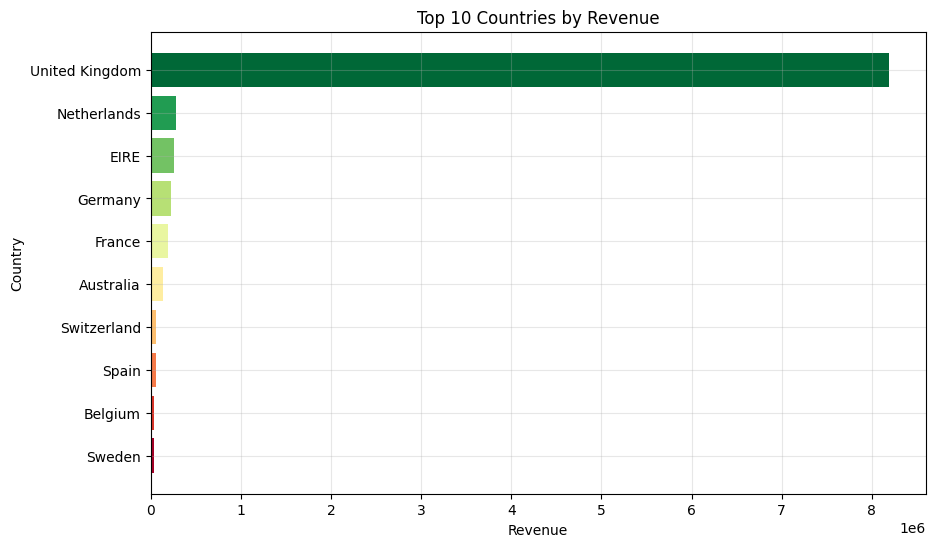

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Revenue by Country
top_revenue = (
    country_revenue
    .sort_values("revenue", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

# Create gradient colors from green to red
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_revenue)))

# Create a horizontal bar chart to visualize the top 10 countries by revenue.
# Why horizontal? Because it allows for better readability of country names 
# and makes it easier to compare revenue values across countries.
# moreover, easier executive readability and presentation purposes.
plt.barh(
    top_revenue["Country"],
    top_revenue["revenue"],
    color=colors
)

plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Revenue")

plt.xlabel("Revenue")
plt.ylabel("Country")

plt.grid(alpha=0.3)

plt.show()

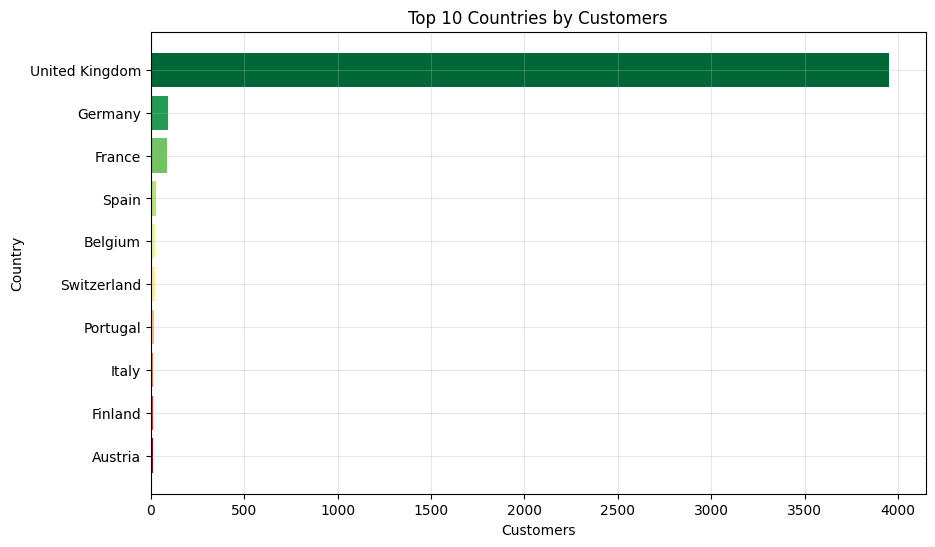

In [ ]:
# Customers by Country
top_customers = (
    country_revenue
    .sort_values("customers", ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

# create a horizontal bar chart to visualize the top 10 countries by customers.
# Why horizontal? Because it allows for better readability of country names 
# and makes it easier to compare customer counts across countries.
# moreover, easier executive readability.
plt.barh(
    top_customers["Country"],
    top_customers["customers"],
    color=colors
)

plt.gca().invert_yaxis()

plt.title("Top 10 Countries by Customers")

plt.xlabel("Customers")
plt.ylabel("Country")

plt.grid(alpha=0.3)

plt.show()

### **Business Questions Solved Using SQL**

**Which customers generate the highest revenue?**
- The analysis identified a small group of high-value customers contributing a significant portion of total revenue.

**Which products drive business performance?**
- A limited number of products generated the majority of sales revenue, indicating strong product concentration.

**Which countries underperform?**
Several countries showed very low revenue and customer counts, suggesting weak market penetration or low demand.

**What is the average order value?**
- The average order value provided insight into typical customer spending behavior per transaction.

**How does revenue trend monthly?**
- Revenue showed strong seasonality, with significant growth during the final quarter of the year, especially around November.

**Which countries contribute most to revenue?**
- The United Kingdom overwhelmingly dominated total revenue generation compared to other markets.

**Which countries have high revenue but few customers?**
- Some countries generated strong revenue despite having very few customers, indicating high customer value concentration.

**Which customer segments are most valuable?**
- VIP Customers and Loyal Customers generated the highest monetary contribution and purchasing frequency.

**How concentrated is revenue across customers?**
- Revenue distribution was highly uneven, with a relatively small customer segment driving a large share of total sales.